In [4]:
## import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

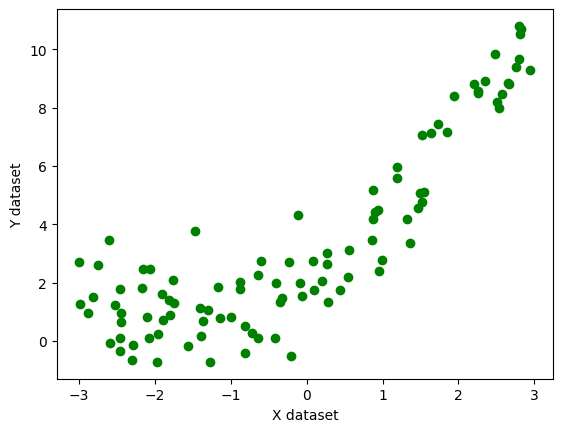

In [5]:
X = 6 * np.random.rand(100 , 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used - y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [8]:
X_train

array([[-1.56586254],
       [-2.52608862],
       [ 1.3157627 ],
       [ 0.85597457],
       [-1.97249023],
       [ 2.81936644],
       [-0.20652982],
       [-0.71796001],
       [-1.27367604],
       [-2.08318722],
       [ 0.44334957],
       [ 2.19999665],
       [-1.13753526],
       [-2.46268269],
       [-1.36816694],
       [-0.10830068],
       [ 1.548243  ],
       [ 2.75890584],
       [ 2.25772385],
       [ 0.54567567],
       [ 0.26782555],
       [-2.60879087],
       [-2.44874307],
       [-1.76130028],
       [-0.87795862],
       [-2.28230035],
       [-0.81417972],
       [-1.46666712],
       [ 0.28585767],
       [-1.79921219],
       [-1.74597619],
       [ 2.47530271],
       [-1.00070394],
       [-0.23434796],
       [ 1.19034694],
       [-1.30329335],
       [-2.59182605],
       [-2.75295501],
       [ 0.26508319],
       [ 0.09848645],
       [-0.05623456],
       [-2.9892836 ],
       [ 0.86995969],
       [-2.06330903],
       [ 2.81258147],
       [ 0

In [9]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.8704375671490693


Text(0, 0.5, 'Y')

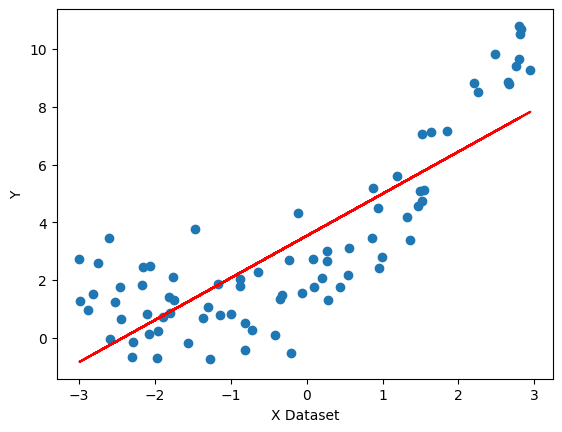

In [11]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [12]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [13]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [14]:
X_train_poly

array([[ 1.00000000e+00, -1.56586254e+00,  2.45192548e+00],
       [ 1.00000000e+00, -2.52608862e+00,  6.38112374e+00],
       [ 1.00000000e+00,  1.31576270e+00,  1.73123148e+00],
       [ 1.00000000e+00,  8.55974571e-01,  7.32692466e-01],
       [ 1.00000000e+00, -1.97249023e+00,  3.89071772e+00],
       [ 1.00000000e+00,  2.81936644e+00,  7.94882715e+00],
       [ 1.00000000e+00, -2.06529817e-01,  4.26545652e-02],
       [ 1.00000000e+00, -7.17960013e-01,  5.15466581e-01],
       [ 1.00000000e+00, -1.27367604e+00,  1.62225067e+00],
       [ 1.00000000e+00, -2.08318722e+00,  4.33966899e+00],
       [ 1.00000000e+00,  4.43349572e-01,  1.96558843e-01],
       [ 1.00000000e+00,  2.19999665e+00,  4.83998526e+00],
       [ 1.00000000e+00, -1.13753526e+00,  1.29398647e+00],
       [ 1.00000000e+00, -2.46268269e+00,  6.06480604e+00],
       [ 1.00000000e+00, -1.36816694e+00,  1.87188079e+00],
       [ 1.00000000e+00, -1.08300681e-01,  1.17290374e-02],
       [ 1.00000000e+00,  1.54824300e+00

In [15]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9156932786626066


In [16]:
print(regression.coef_)

[[0.         1.50780545 0.50104092]]


In [17]:
print(regression.intercept_)

[1.9487476]


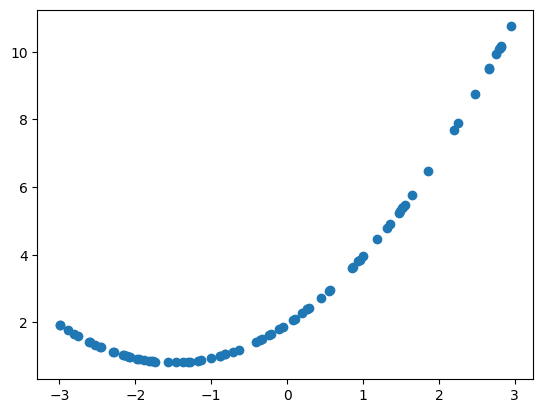

In [18]:
plt.scatter(X_train,regression.predict(X_train_poly))

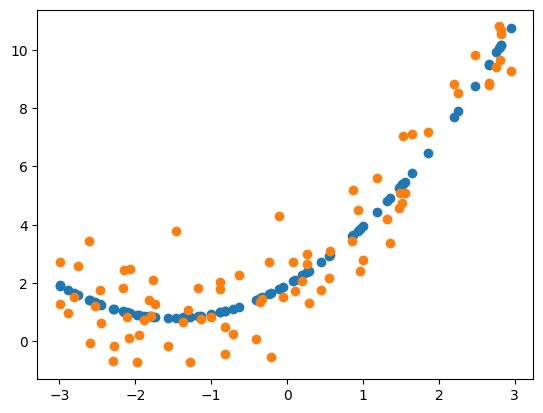

In [19]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [20]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [21]:
X_train_poly

array([[ 1.00000000e+00, -1.56586254e+00,  2.45192548e+00,
        -3.83937825e+00],
       [ 1.00000000e+00, -2.52608862e+00,  6.38112374e+00,
        -1.61192841e+01],
       [ 1.00000000e+00,  1.31576270e+00,  1.73123148e+00,
         2.27788981e+00],
       [ 1.00000000e+00,  8.55974571e-01,  7.32692466e-01,
         6.27166120e-01],
       [ 1.00000000e+00, -1.97249023e+00,  3.89071772e+00,
        -7.67440270e+00],
       [ 1.00000000e+00,  2.81936644e+00,  7.94882715e+00,
         2.24106565e+01],
       [ 1.00000000e+00, -2.06529817e-01,  4.26545652e-02,
        -8.80943955e-03],
       [ 1.00000000e+00, -7.17960013e-01,  5.15466581e-01,
        -3.70084393e-01],
       [ 1.00000000e+00, -1.27367604e+00,  1.62225067e+00,
        -2.06622181e+00],
       [ 1.00000000e+00, -2.08318722e+00,  4.33966899e+00,
        -9.04034297e+00],
       [ 1.00000000e+00,  4.43349572e-01,  1.96558843e-01,
         8.71442789e-02],
       [ 1.00000000e+00,  2.19999665e+00,  4.83998526e+00,
      

In [22]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9162902481038471


In [23]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

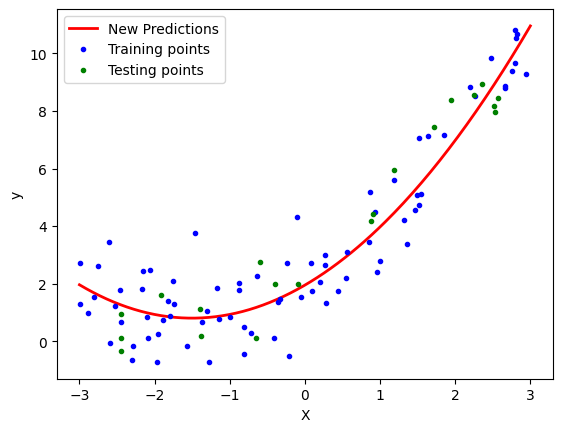

In [24]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [25]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
        ])
    poly_regression.fit(X_train, y_train)   ## Polynomial and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)

    # Plotting prediction line
    plt.plot(X_new, y_pred_new, "r", label="Degree " + str(degree), linewidth=3)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

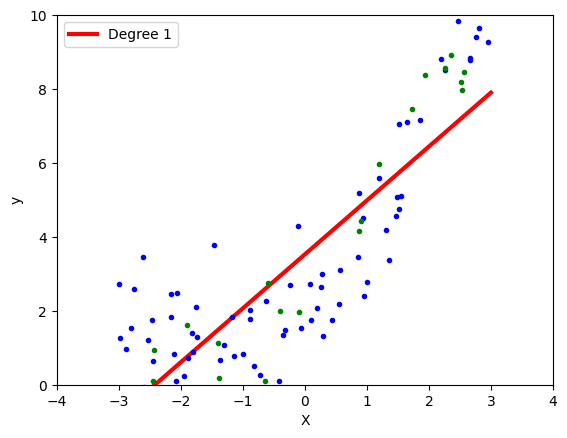

In [28]:
poly_regression(1)

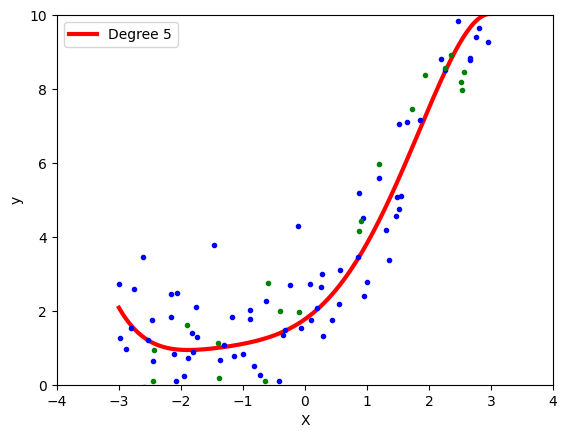

In [27]:
poly_regression(5)

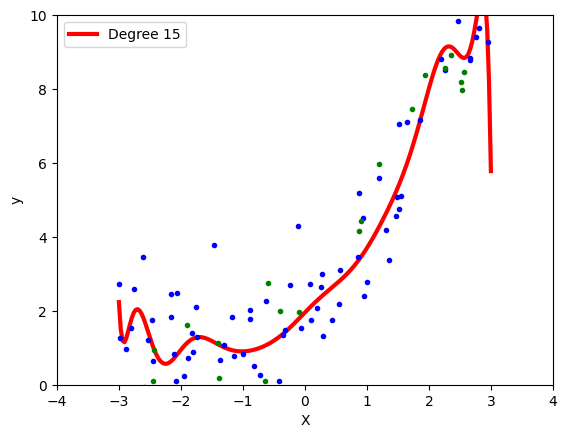

In [29]:
poly_regression(15)

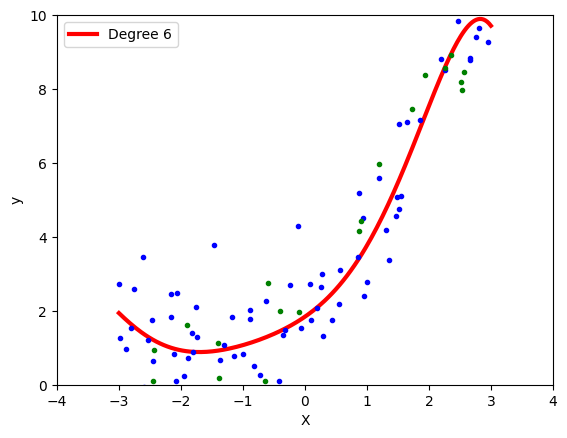

In [30]:
poly_regression(6)